In [5]:
import xarray as xr
import numpy as np
import jax.numpy as jnp

from scipy.signal.windows import tukey

import sys
sys.path.append('./subroutine')
from rfft2 import rfft2, irfft2
from rel_err import rel_err
from isospec_rfft import isospec_rfft

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo
plt.style.use('/mnt/c/Ryan_Data/Python_Tool/ryan_mplstyle.mplstyle')

OSError: '/mnt/c/Ryan_Data/Python_Tool/ryan_mplstyle.mplstyle' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [ ]:
# ds = xr.open_dataset("data/data_channel/channel_snap.nc")
ds_truth = xr.open_dataset("data/data_channel/processed/truth.nc") # This is a different data from notebook 0

ds_truth

<xarray.Dataset> Size: 9MB
Dimensions:         (x: 400, y: 400)
Coordinates:
    x               (x, y) float32 640kB ...
    y               (x, y) float32 640kB ...
Data variables:
    U_surface       (x, y) float64 1MB ...
    V_surface       (x, y) float64 1MB ...
    Eta             (x, y) float64 1MB ...
    zeta_surface    (x, y) float64 1MB ...
    strain_surface  (x, y) float64 1MB ...
    div_surface     (x, y) float64 1MB ...
    f               float64 8B ...
    g               float64 8B ...

In [ ]:
# Load the truth back in
x = ds_truth.x.values
y = ds_truth.y.values

Eta = ds_truth.Eta.values

U_surface = ds_truth.U_surface.values
V_surface = ds_truth.V_surface.values

zeta_surface = ds_truth.zeta_surface.values
div_surface = ds_truth.div_surface.values
strain_surface = ds_truth.strain_surface.values

g = ds_truth.g.values

In [ ]:
# Function to detrend
def get_basis(x, y, max_order=4):
    """Return the fit basis polynomials: 1, x, x^2, ..., xy, x^2y, ... etc."""
    basis = []
    for i in range(max_order+1):
        for j in range(max_order - i+1):
            basis.append(x**j * y**i)
    return np.array(basis)

# Maximum order of polynomial term in the basis.
max_order = 2

def detrend_2d(X, Y, input_d):
    A = get_basis(X.ravel(), Y.ravel(), max_order).T

    b = input_d.ravel()
    c, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    
    fit = (A @ c).reshape(X.shape[0],X.shape[1])
    return 1*input_d+(-1)*fit

In [ ]:
# Windowing using tuckey, to make periodic
cut_id = (np.round(x.shape[0]/2*0.3)+1).astype(int)
Tw2d = np.outer(tukey(x.shape[0], alpha=0.3),tukey(y.shape[1], alpha=0.3))

Eta_detrend = detrend_2d(x,y,Eta)
Eta_windowed = Eta_detrend*Tw2d

zeta_detrend = detrend_2d(x,y,zeta_surface)
zeta_windowed = zeta_detrend*Tw2d
zeta_windowed -= np.mean(zeta_windowed)

0.0


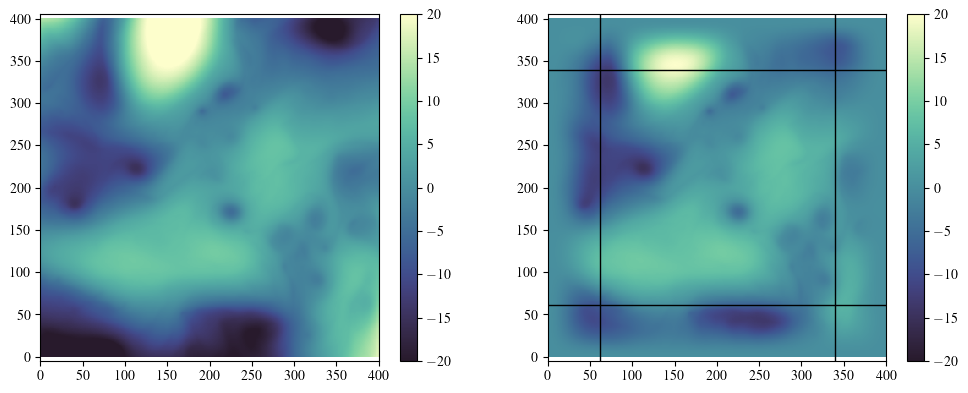

In [6]:
plt.figure(figsize=(12,4.5))

plt.subplot(121)
plt.pcolor(x/1000,y/1000,Eta_detrend*100, cmap=cmo.deep_r ,vmin=-20,vmax=20)
plt.axis('equal')
plt.colorbar()

plt.subplot(122)
plt.pcolor(x/1000,y/1000,Eta_windowed*100, cmap=cmo.deep_r ,vmin=-20,vmax=20)
plt.axhline(x[0,cut_id]/1000,color='k'); plt.axhline(y[-cut_id,0]/1000,color='k'); 
plt.axvline(x[0,cut_id]/1000,color='k'); plt.axvline(y[-cut_id,0]/1000,color='k'); 
plt.axis('equal')
plt.colorbar()

plt.show

print(rel_err(Eta_detrend,Eta_windowed,cut_id))

In [ ]:
# Reduction of variance from the windowing procedure, saved for the magnitude of the spectrum 
var_window = np.var(Eta.ravel())/np.var(Eta_windowed.ravel())
print(var_window)

7.874988568645051


In [8]:
L_domain = 400 # size of the domain in km

k_domain_factor = 1/L_domain # convert to cpkm

In [ ]:
# Get the isotropic spectrum
Eta_spec = isospec_rfft( np.abs(rfft2(Eta_windowed*100))**2 ) # cm^2
Eta_spec /= k_domain_factor # cm^2/cpkm

zeta_spec = isospec_rfft( np.abs(rfft2(zeta_windowed))**2 ) 
zeta_spec /= k_domain_factor # cm^2/cpkm

print(np.sum(Eta_spec) *k_domain_factor )
print(np.sum( (Eta_windowed*100)**2 ) / Eta_windowed.size)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


35.812935642660605
30.00188491956529


/tmp/ipykernel_1309/1576428228.py:7: RuntimeWarning: divide by zero encountered in power
  plt.loglog(k_cpkm,2+1.25e-3*k_cpkm**(-2))


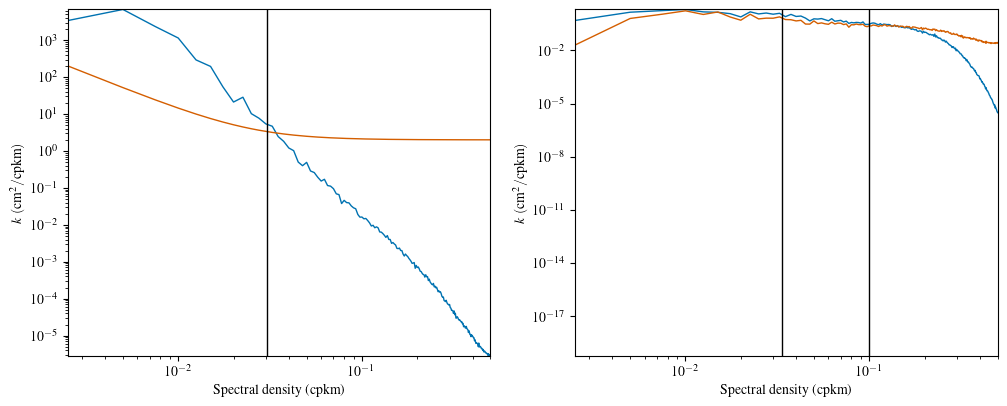

In [ ]:
k_cpkm = np.arange(0,Eta_spec.size,1.)*(k_domain_factor)

plt.figure(figsize=(12,4.5))

plt.subplot(121)
# Why did I turn off varwindow
plt.loglog(k_cpkm,Eta_spec  *var_window**0  )
# The engineering specification from Callies and Wu 19
plt.loglog(k_cpkm,2+1.25e-3*k_cpkm**(-2))

plt.axvline(1/33,color='k')

plt.xlabel("Spectral density ($\mathrm{cpkm}$)")
plt.ylabel("$k\ (\mathrm{cm}^2/\mathrm{cpkm})$")

plt.subplot(122)
press_spec = Eta_spec*((g/100)**2) # Achtung, this is the SSH (SS pressure)
k_pim = k_cpkm*100*(2*np.pi)

plt.loglog(k_cpkm,zeta_spec) # zeta spec
plt.loglog(k_cpkm,press_spec *(k_pim)**4/1e4) #geostrophic spec, up to a factor
# The geostrophic version is flat. Real velocity has dissipation while SSH does not. How does MITgcm get SSH anyway?

plt.xlabel("Spectral density ($\mathrm{cpkm}$)")
plt.ylabel("$k\ (\mathrm{cm}^2/\mathrm{cpkm})$")
# plt.ylim(1e0,1e5)

# Random vertical lines
plt.axvline(1/30,color='k')
plt.axvline(1/10,color='k')

In [ ]:
# Define the lowpassfilter for the rest of the notebooks! Remove small-scales of the SSH fields. 
dx = 1 #km
kx_cpkm = np.fft.rfftfreq(Eta_windowed.shape[1],d=dx)
ky_cpkm = np.fft.fftfreq (Eta_windowed.shape[0],d=dx)
kxmat_cpkm, kymat_cpkm = np.meshgrid(kx_cpkm, ky_cpkm)

K2mat_cpkm = (kxmat_cpkm**2+kymat_cpkm**2)
Kamat_cpkm = np.sqrt(K2mat_cpkm)
# Kaa = Ka.at[0,0].set(1e10)

lowpass_filter = np.ones(Kamat_cpkm.shape); 
pass_k = 1/30 # this is the filter scale
lowpass_filter = np.array(  np.exp(-(Kamat_cpkm-pass_k)**2*20)  ) # This is the shape, I made this up from Smith 2002
lowpass_filter[Kamat_cpkm<pass_k] = 1

In [ ]:
# Convention, "__" is Fourier modes
Eta_windowed__ = rfft2(Eta_windowed)
Eta_lpfilter__ = Eta_windowed__*lowpass_filter**1

Eta_lpf_spec = isospec_rfft( np.abs(Eta_lpfilter__*100)**2 ) # cm^2
Eta_lpf_spec /= k_domain_factor # cm^2/cpkm

zeta_lpfilter__ = rfft2(zeta_windowed)*lowpass_filter**1
zetata_lpf_spec = isospec_rfft( np.abs(zeta_lpfilter__)**2 )
zetata_lpf_spec /= k_domain_factor

In [13]:
f = ds_truth.f.values

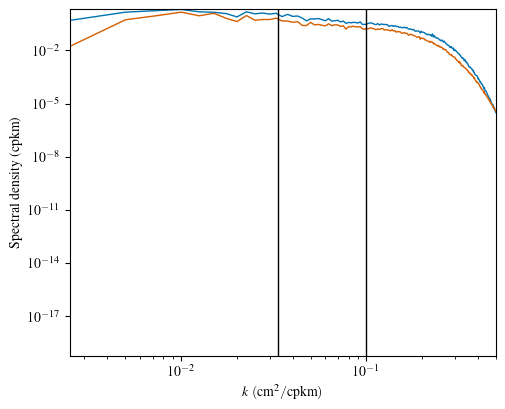

In [14]:
plt.figure(figsize=(5.5,4.5))

press_lpf_spec = Eta_lpf_spec*((g/100)**2)
k_pim = k_cpkm*100*(2*np.pi)

plt.loglog(k_cpkm,zeta_spec)
# plt.loglog(k_cpkm,zetata_lpf_spec)
# plt.loglog(k_cpkm,press_spec *(k_pim)**4*f)
plt.loglog(k_cpkm,press_lpf_spec *(k_pim)**4*np.abs(f))

plt.xlabel("$k\ (\mathrm{cm}^2/\mathrm{cpkm})$")
plt.ylabel("Spectral density ($\mathrm{cpkm}$)")
# plt.ylim(1e-2,1e5)

# plt.ylim([1e-5,3])
plt.axvline(1/30,color='k')
plt.axvline(1/10,color='k')

In [ ]:
# Save the lowpassed and windowed fields
press_lpfilter = irfft2(Eta_lpfilter__)*g
zeta_windowed = zeta_windowed

In [ ]:
d_save = xr.Dataset(
    
    # dims=["x", "y"],
    coords=dict(
        x=(["x", "y"], ds_truth.x.values),
        y=(["x", "y"], ds_truth.y.values),
    ),
)

d_save["lowpass_filter"]=(["kx", "ky"],  lowpass_filter) # Saved the filter to use the all the rest
d_save["press_lpfilter"]=(["x", "y"],  press_lpfilter)
d_save["zeta_windowed"]=(["x", "y"],  zeta_windowed)
d_save["cut_id"]=(cut_id) # this is the windowing index. Use for plotting later

In [17]:
d_save

<xarray.Dataset> Size: 4MB
Dimensions:         (x: 400, y: 400, kx: 400, ky: 201)
Coordinates:
    x               (x, y) float32 640kB 500.0 1.5e+03 ... 3.985e+05 3.995e+05
    y               (x, y) float32 640kB 500.0 500.0 ... 3.995e+05 3.995e+05
Dimensions without coordinates: kx, ky
Data variables:
    lowpass_filter  (kx, ky) float64 643kB 1.0 1.0 1.0 ... 0.01345 0.01283
    press_lpfilter  (x, y) float32 640kB -6.069e-08 2.85e-07 ... -2.804e-07
    zeta_windowed   (x, y) float64 1MB 0.001907 0.001907 ... 0.001907 0.001907
    cut_id          int64 8B 61

In [18]:
d_save.to_netcdf('data/data_channel/processed/Fourier_lpfilter.nc')